This notebook demonstrates the main ideas of our code. Here `TICKERS` denotes a list of ticker symbols in our portfolio. The `START_DATE` and `END_DATE` are start and end dates for historical analysis of the stocks in the portfolio.

In [40]:
from var_config import TICKERS, START_DATE, END_DATE, RISK_FREE_RATE
from dataloader import *

## Getting price data 

We download historical data from Yahoo finance. We have a dataframe of daily closing prices for every stock in the portfolio, using the `load_price_data` function and we compute the percentage change returns using `compute_returns`. Note that yfinance has incomplete data which is why there may be missing dates in the date column.

In [41]:
prices = load_price_data(TICKERS, START_DATE, END_DATE)
prices

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2016-01-04,23.709101,31.849501,37.660732,101.424080,47.770721
2016-01-05,23.114965,31.689501,37.764374,101.930115,47.988663
2016-01-06,22.662611,31.632500,37.655277,102.168236,47.116924
2016-01-07,21.706152,30.396999,36.746288,97.157562,45.478073
2016-01-08,21.820927,30.352501,36.245930,96.572151,45.617550
...,...,...,...,...,...
2025-12-24,273.302216,232.380005,313.869049,666.978943,485.856323
2025-12-26,272.893005,232.520004,313.289459,662.722595,485.547729
2025-12-29,273.252350,232.070007,313.339417,658.126526,484.940430


In [42]:
returns = compute_returns(prices)
returns

Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2016-01-05,-0.025059,-0.005024,0.002752,0.004989,0.004562
2016-01-06,-0.019570,-0.001799,-0.002889,0.002336,-0.018166
2016-01-07,-0.042204,-0.039058,-0.024140,-0.049043,-0.034783
2016-01-08,0.005288,-0.001464,-0.013617,-0.006025,0.003067
2016-01-11,0.016192,0.017610,0.002955,0.001849,-0.000573
...,...,...,...,...,...
2025-12-24,0.005324,0.001034,-0.000827,0.003925,0.002403
2025-12-26,-0.001497,0.000602,-0.001847,-0.006382,-0.000635
2025-12-29,0.001317,-0.001935,0.000159,-0.006935,-0.001251


## Backtesting

The `run_backtest` function allows us to run backtests on the dataframe of returns. We can adjust (1) the lookback period (the second argument) which determines the window for looking at past data and (2) the rebalancing period (the third argument) which determines the window for keeping the optimal weights determined from the lookback period. The weights are optimized to maximize the Sharpe ratio. Here, we use 252 days for the lookback period and 7 days for the rebalancing period.

The output of this function consists of a series `strategy_returns` which describes the mean returns of the portfolio during the rebalancing period. Similarly, the series of `benchmark_returns` describes the mean returns of an equal-weight portfolio. Finally, `weights_df` is a dataframe describing the weights used for each stock in each rebalancing period.

In [43]:
from backtest import run_backtest

In [44]:
strategy_returns, benchmark_returns, weights_df = run_backtest(
    returns, 252, 7, RISK_FREE_RATE
)

In [45]:
strategy_returns

0      0.004395
1      0.001666
2      0.003948
3      0.002006
4      0.002973
         ...   
318    0.001542
319    0.010800
320    0.002563
321   -0.005772
322    0.002712
Length: 323, dtype: float64

In [46]:
benchmark_returns

0      0.006053
1      0.002207
2      0.001777
3      0.003185
4      0.002044
         ...   
318   -0.005832
319    0.007549
320   -0.000187
321   -0.001349
322    0.000721
Length: 323, dtype: float64

In [47]:
weights_df

Ticker,AAPL,AMZN,GOOGL,META,MSFT
2017-01-04,1.514869e-01,3.214032e-01,2.374105e-16,1.927996e-02,5.078300e-01
2017-01-13,3.250510e-01,3.923633e-01,0.000000e+00,1.829437e-01,9.964192e-02
2017-01-25,2.751644e-01,3.128610e-01,0.000000e+00,2.070406e-01,2.049340e-01
2017-02-03,3.924203e-01,6.075797e-01,1.686981e-16,0.000000e+00,5.732354e-17
2017-02-14,4.199946e-01,5.664503e-01,1.913600e-16,5.423699e-03,8.131414e-03
...,...,...,...,...,...
2025-11-11,0.000000e+00,1.110223e-16,1.000000e+00,0.000000e+00,3.885781e-16
2025-11-20,3.053113e-16,1.387779e-16,1.000000e+00,0.000000e+00,0.000000e+00
2025-12-02,2.775558e-17,1.387779e-16,1.000000e+00,5.551115e-17,1.665335e-16
2025-12-11,0.000000e+00,1.387779e-16,1.000000e+00,0.000000e+00,5.273559e-16


## Visualizations

Here are some graphs comparing the two strategies. The cumulative returns of the two strategies can be expressed by the product $\prod_i(1+r_i)$ where $ r_i $ are the succesive returns in either of the two series. Expectedly, the optimized portfolio performs better with the variables (252,7), but if they are changed to (504,21), the optimized portfolio performs worse because of overfitting.

In [48]:
from visualizations import *

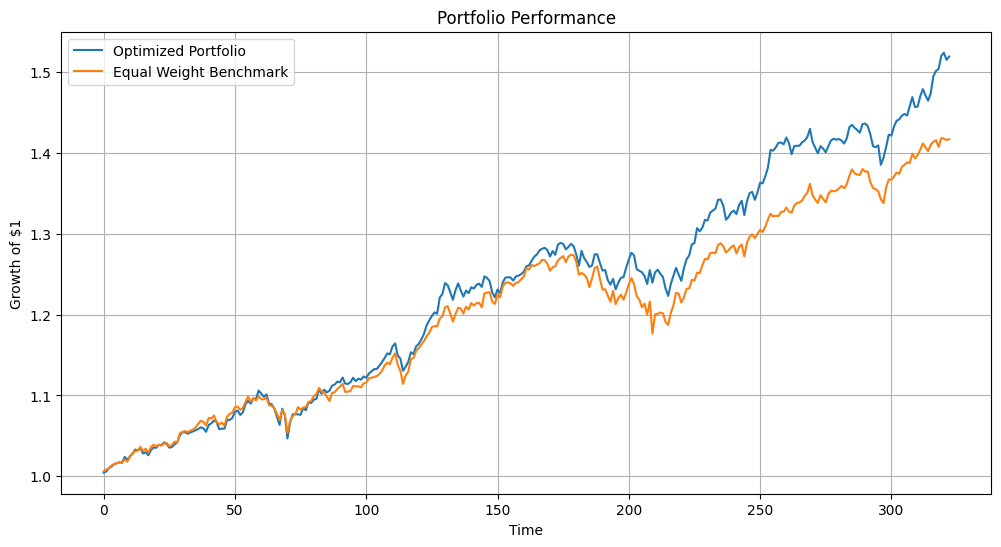

In [49]:
plot_cumulative_returns(strategy_returns, benchmark_returns)

In [50]:
strategy_returns, benchmark_returns, weights_df = run_backtest(
    returns, 504, 21, RISK_FREE_RATE
)

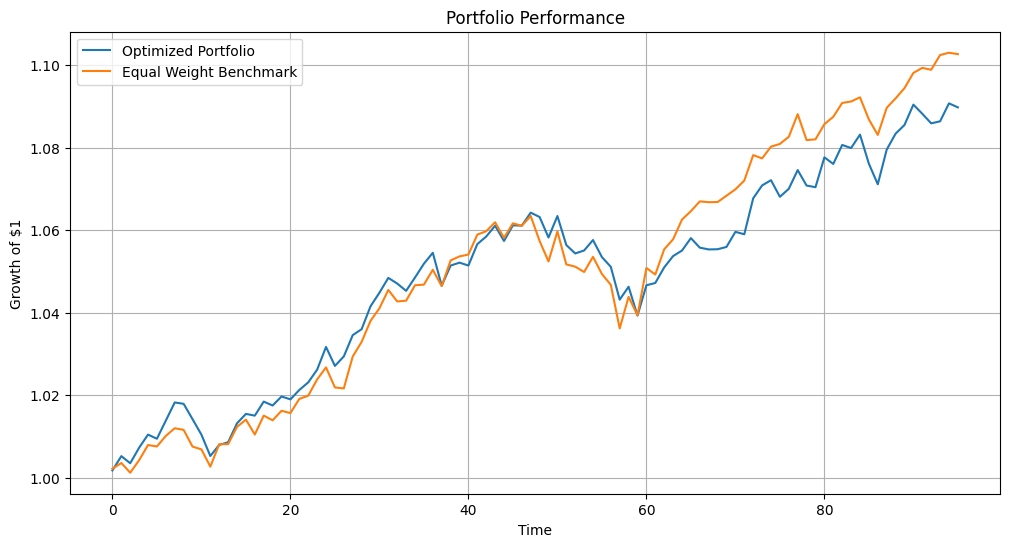

In [51]:
plot_cumulative_returns(strategy_returns, benchmark_returns)

In [52]:
import main

In [53]:
strategy_df, benchmark_df = main.main()

[*********************100%***********************]  5 of 5 completed

Running backtests...


Process complete!


We compare the Sharpe ratios for a given lookback period with various rebalancing frequencies. As in the previous graph, if the lookback period is too long (504 days), then the optimized portfolio performs worse than the naive one. With shorter lookback periods (126 or 252 days), we find that the optimized portfolio does give a better Sharpe ratio provided that we rebalance with the correct frequency, i.e. we do not rebalance too often (1 day), or we do not stay put for too long (21 days) with the optimal weights.

In [54]:
from visualizations import sharpe_ratio_bar_graph

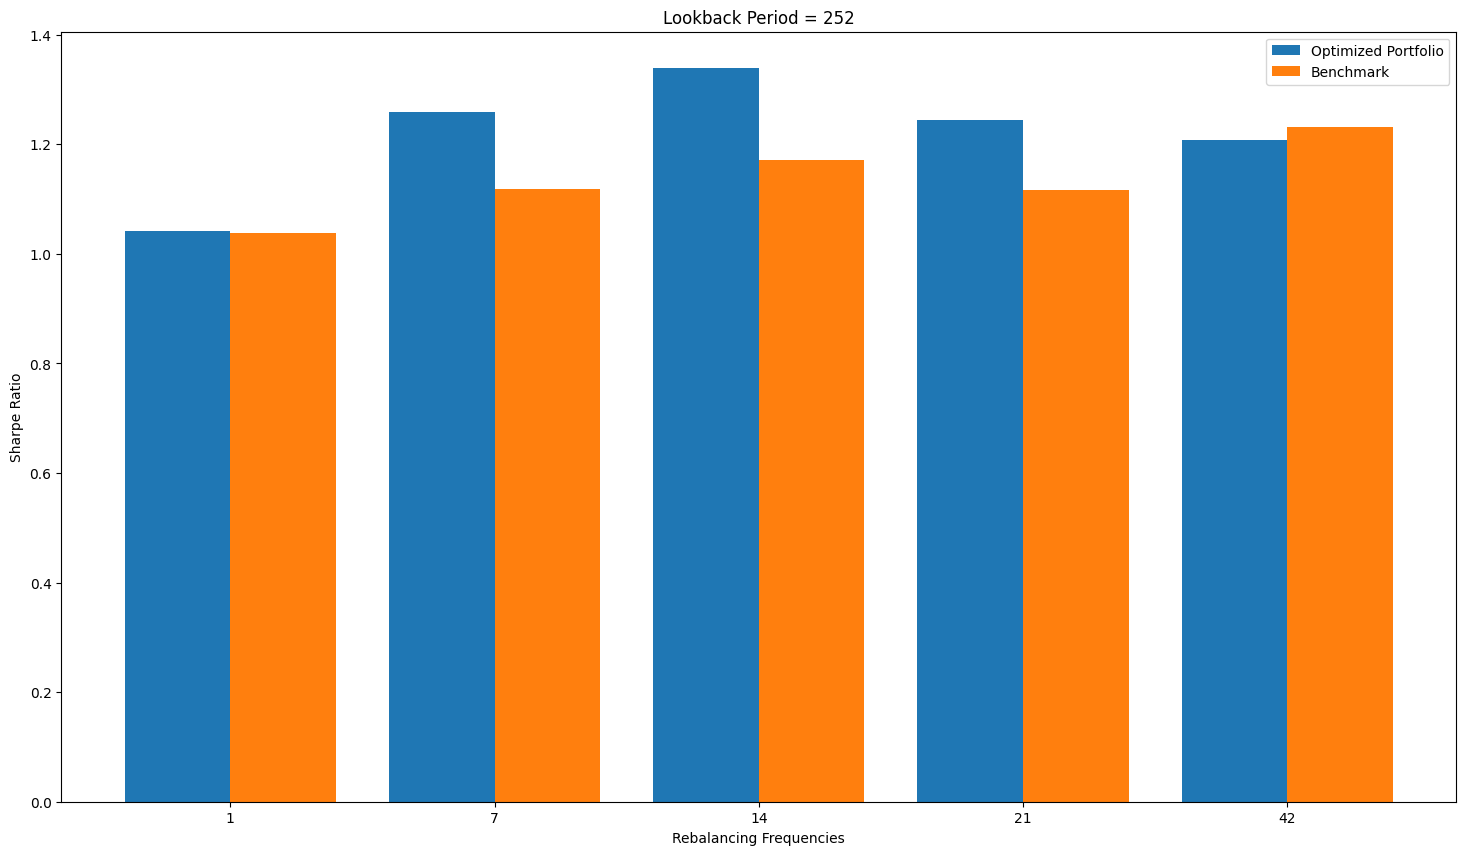

In [55]:
sharpe_ratio_bar_graph(strategy_df.loc[252], benchmark_df.loc[252], 252)

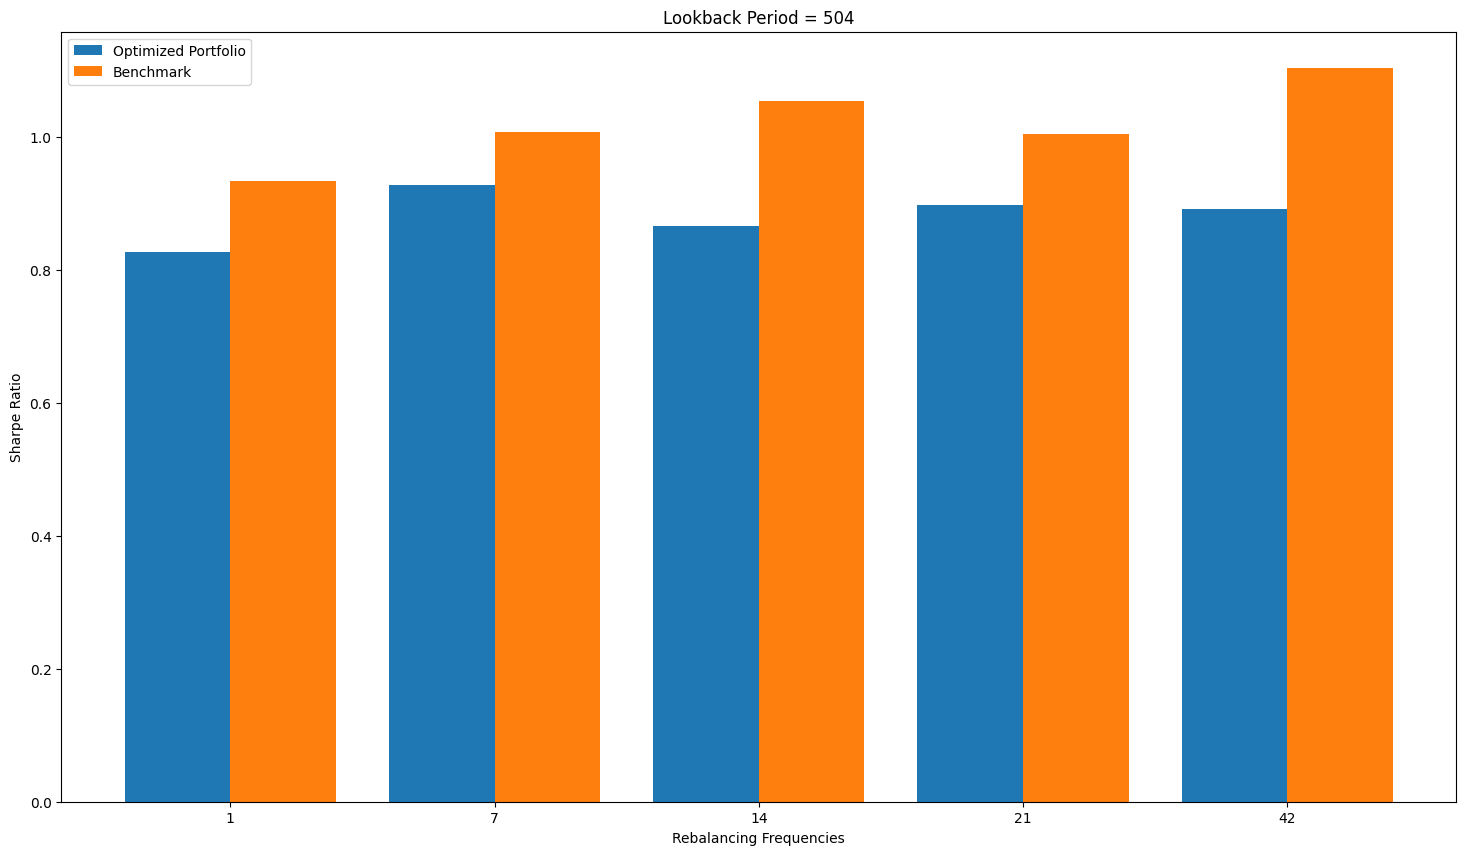

In [56]:
sharpe_ratio_bar_graph(strategy_df.loc[504], benchmark_df.loc[504], 504)

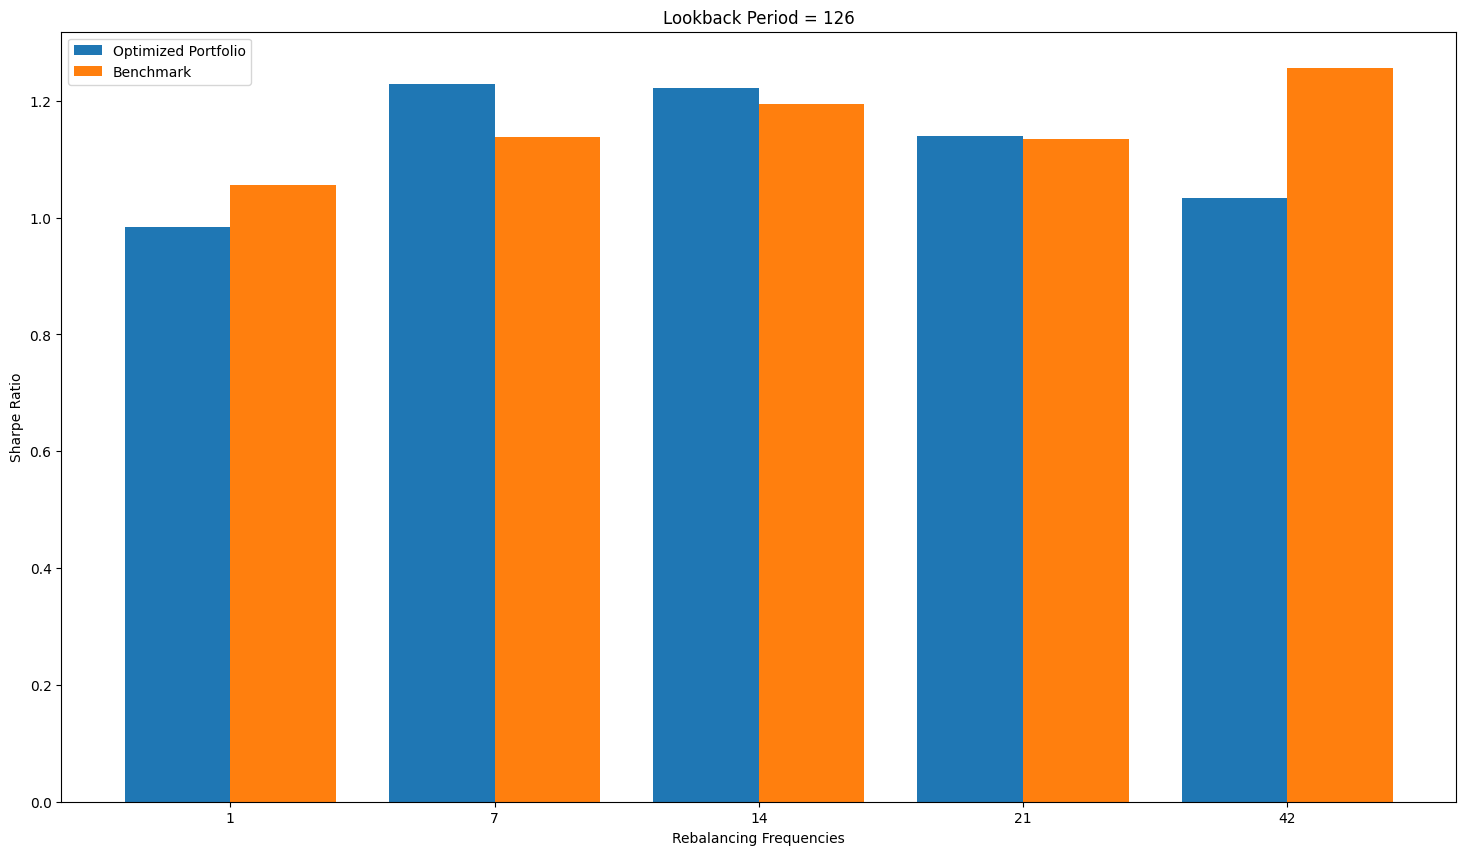

In [57]:
sharpe_ratio_bar_graph(strategy_df.loc[126], benchmark_df.loc[126], 126)